In [ ]:
from google.colab import files

# This will open a file selection dialog in your browser
files.upload()

In [ ]:
import numpy as np
import pandas as pd
from scipy.special import gammaln

df = pd.read_csv("datast.csv")

temps = df['temperature_2m (°C)'].dropna().values

def log_marginal_nig(data, mu0, kappa0, alpha0, beta0):
    n = data.size
    if n == 0:
        return 0.0
    xbar = data.mean()
    ssum = ((data - xbar)**2).sum()
    kappa_n = kappa0 + n
    alpha_n = alpha0 + 0.5 * n
    beta_n = beta0 + 0.5 * ssum + 0.5 * (kappa0 * n / kappa_n) * (xbar - mu0)**2

    logZ0 = alpha0 * np.log(beta0) - gammaln(alpha0) + 0.5 * np.log(kappa0 / (2.0 * np.pi))
    logZn = alpha_n * np.log(beta_n) - gammaln(alpha_n) + 0.5 * np.log(kappa_n / (2.0 * np.pi))
    return logZ0 - logZn

data = temps
mu0 = 25.0
kappa0 = 1e-6
alpha0 = 2.0
beta0  = 1.0

log_m1 = log_marginal_nig(data, mu0=mu0, kappa0=kappa0, alpha0=alpha0, beta0=beta0)

def log_marginal_sigma_only(data, mu_fixed, alpha0, beta0):
    n = data.size
    xbar = data.mean()
    ssum = ((data - mu_fixed)**2).sum()
    alpha_n = alpha0 + 0.5 * n
    beta_n = beta0 + 0.5 * ssum
    logZ0 = alpha0 * np.log(beta0) - gammaln(alpha0)
    logZn = alpha_n * np.log(beta_n) - gammaln(alpha_n)
    return logZ0 - logZn - 0.5 * n * np.log(2 * np.pi)

log_m0 = log_marginal_sigma_only(data, mu_fixed=mu0, alpha0=alpha0, beta0=beta0)

logBF10 = log_m1 - log_m0
BF10 = np.exp(logBF10)
print("log BF10 =", logBF10, " BF10 =", BF10)


log BF10 = 8964.85231273522  BF10 = inf


/tmp/ipython-input-4109304409.py:59: RuntimeWarning: overflow encountered in exp
  BF10 = np.exp(logBF10)


In [ ]:
# one_sided_variance_test.py
import numpy as np
import pandas as pd
from scipy.special import gammaln
from scipy.stats import invgamma
from scipy import integrate

# -------------------------
# Helper: posterior params for Inv-Gamma (from NIG conjugacy)
# -------------------------
def posterior_inv_gamma_params(data, mu0, kappa0, alpha0, beta0):
    n = data.size
    if n == 0:
        raise ValueError("Empty data.")
    xbar = data.mean()
    ssum = ((data - xbar)**2).sum()
    kappa_n = kappa0 + n
    alpha_n = alpha0 + 0.5 * n
    beta_n = beta0 + 0.5 * ssum + 0.5 * (kappa0 * n / kappa_n) * (xbar - mu0)**2
    return alpha_n, beta_n

# -------------------------
# Load data
# -------------------------
df = pd.read_csv("datast.csv")
wind = df['wind_speed_100m (km/h)'].dropna()
day = wind[df['is_day ()'] == 1].dropna().values
night = wind[df['is_day ()'] == 0].dropna().values

n_day = len(day)
n_night = len(night)
assert n_day >= 2 and n_night >= 2, "Need >=2 observations per group."

# -------------------------
# Prior hyperparameters (use same as before)
# -------------------------
alpha0 = 3.0
beta0 = 50.0
kappa0 = 1e-6
# center mean prior at pooled mean (weak prior)
mu0 = np.concatenate([day, night]).mean()

# -------------------------
# Posterior parameters (Inv-Gamma) for sigma^2 in each group
# -------------------------
a_day, b_day = posterior_inv_gamma_params(day, mu0, kappa0, alpha0, beta0)
a_night, b_night = posterior_inv_gamma_params(night, mu0, kappa0, alpha0, beta0)

# Posterior PDFs/CDFs
from scipy.stats import invgamma
pdf_day = lambda s2: invgamma.pdf(s2, a=a_day, scale=b_day)
cdf_day = lambda s2: invgamma.cdf(s2, a=a_day, scale=b_day)
pdf_night = lambda s2: invgamma.pdf(s2, a=a_night, scale=b_night)

# -------------------------
# Compute posterior probability P(sigma_day^2 <= sigma_night^2 | data)
# P = ∫_0^∞ p_night(s2) * CDF_day(s2) ds2
# -------------------------
def integrand(s2):
    return pdf_night(s2) * cdf_day(s2)

P_H0_post, err = integrate.quad(integrand, 0.0, np.inf, epsabs=1e-10, epsrel=1e-10, limit=200)
P_H1_post = 1.0 - P_H0_post

# -------------------------
# Compute prior probability P(H0) by Monte-Carlo sampling from prior
# (optional but recommended if priors are not symmetric)
# -------------------------
n_prior_samples = 200000
s2_day_prior = invgamma.rvs(a=alpha0, scale=beta0, size=n_prior_samples)
s2_night_prior = invgamma.rvs(a=alpha0, scale=beta0, size=n_prior_samples)
P_H0_prior = np.mean(s2_day_prior <= s2_night_prior)
P_H1_prior = 1.0 - P_H0_prior

# -------------------------
# Bayes factor for one-sided hypothesis:
# BF10 = (posterior odds) / (prior odds)
#       = [P(H1|data)/P(H0|data)] / [P(H1)/P(H0)]
# If priors symmetric P(H0)=0.5 -> BF10 = P(H1|data)/P(H0|data)
# -------------------------
eps = 1e-323  # avoid divide by zero
p0_post = max(P_H0_post, eps)
p0_prior = max(P_H0_prior, eps)

posterior_odds = (1.0 - p0_post) / p0_post
prior_odds = (1.0 - p0_prior) / p0_prior
BF10_one_sided = posterior_odds / prior_odds
log10_BF10_one_sided = np.log10(BF10_one_sided) if np.isfinite(BF10_one_sided) else np.inf

# -------------------------
# Print results (compact)
# -------------------------
print("=== One-sided variance test (day vs night) ===")
print(f"n_day = {n_day}, n_night = {n_night}")
print()
print("Posterior (sigma^2):")
print(f"  day:  Inv-Gamma(a={a_day:.3f}, b={b_day:.3f})")
print(f"  night:Inv-Gamma(a={a_night:.3f}, b={b_night:.3f})")
print()
print("Posterior probability (H0: sigma2_day <= sigma2_night):")
print(f"  P(H0 | data) = {P_H0_post:.6e}")
print(f"  P(H1 | data) = {P_H1_post:.6e}")
print()
print("Prior probability (Monte-Carlo):")
print(f"  P(H0) = {P_H0_prior:.6f},  P(H1) = {P_H1_prior:.6f}")
print()
print("One-sided Bayes factor (H1 vs H0):")
print(f"  BF10 = {BF10_one_sided:.4e}")
print(f"  log10 BF10 = {log10_BF10_one_sided:.4f}")


=== One-sided variance test (day vs night) ===
n_day = 4625, n_night = 4519

Posterior (sigma^2):
  day:  Inv-Gamma(a=2315.500, b=141893.961)
  night:Inv-Gamma(a=2262.500, b=103311.408)

Posterior probability (H0: sigma2_day <= sigma2_night):
  P(H0 | data) = 5.391394e-116
  P(H1 | data) = 1.000000e+00

Prior probability (Monte-Carlo):
  P(H0) = 0.499545,  P(H1) = 0.500455

One-sided Bayes factor (H1 vs H0):
  BF10 = 1.8514e+115
  log10 BF10 = 115.2675


***Grid approximation***

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

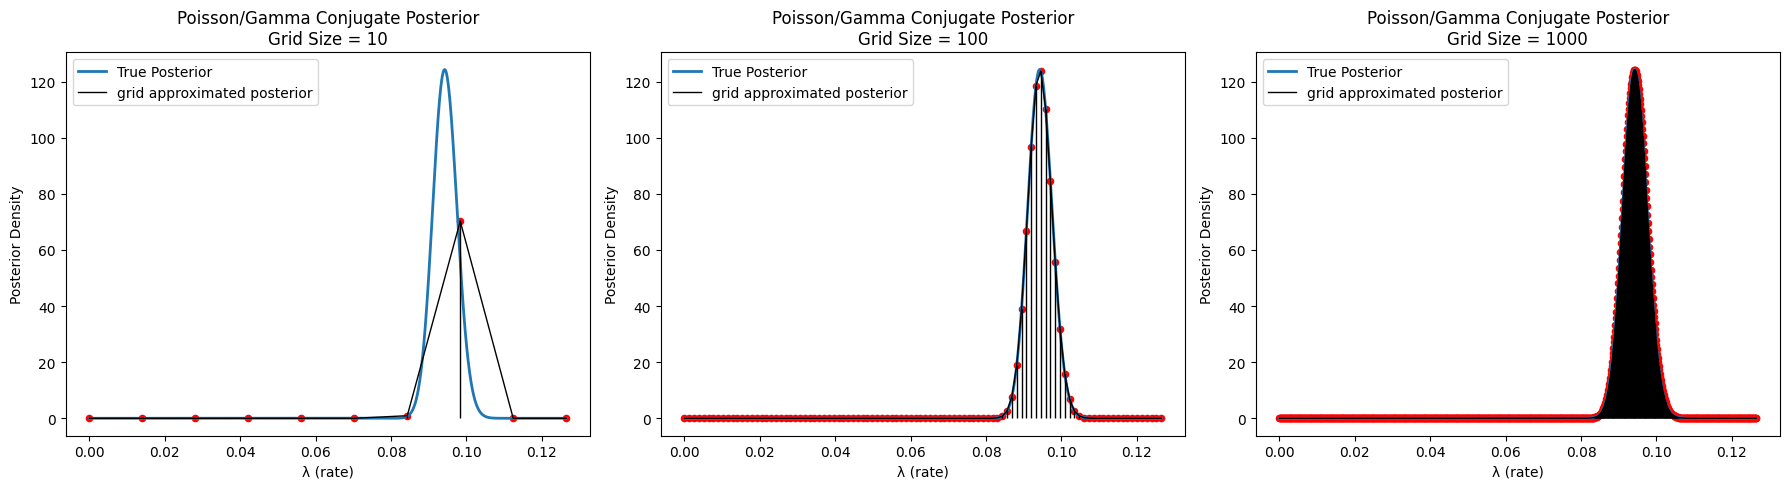

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma

# --------------------------
# Load data
# --------------------------
df = pd.read_csv("datast.csv")
prec = df['precipitation (mm)'].dropna().values
n = len(prec)

# --------------------------
# Prior (Gamma)
# --------------------------
alpha0 = 2
beta0 = 1   # rate parameter (Gamma(shape, rate))

# --------------------------
# Posterior (Gamma: conjugate)
# --------------------------
alpha_post = alpha0 + prec.sum()
beta_post = beta0 + n

# --------------------------
# Posterior mean and std
# --------------------------
lam_mean = alpha_post / beta_post
lam_sd = np.sqrt(alpha_post) / beta_post

# Use zoomed range focused on posterior mass
lam_max = lam_mean + 10 * lam_sd
lam_true = np.linspace(0, lam_max, 2000)

# True posterior density (analytic)
posterior_true = gamma.pdf(lam_true, a=alpha_post, scale=1/beta_post)
posterior_true /= np.trapz(posterior_true, lam_true)   # normalize

# --------------------------
# Grid Approximation
# --------------------------
grid_sizes = [10, 100, 1000]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, G in zip(axes, grid_sizes):
    lam_grid = np.linspace(0, lam_max, G)

    # Unnormalized grid posterior
    post_grid = gamma.pdf(lam_grid, a=alpha_post, scale=1/beta_post)
    post_grid /= np.trapz(post_grid, lam_grid)   # normalize

    # Plot true posterior
    ax.plot(lam_true, posterior_true, label="True Posterior", linewidth=2)

    # grid vertical lines
    ax.vlines(lam_grid, ymin=0, ymax=post_grid, color='black', linewidth=1)

    # Plot grid approximation
    ax.scatter(lam_grid, post_grid, color='red', s=20,)

    # ---- NEW: connect the grid points with a line ----
    ax.plot(lam_grid, post_grid, color='black', linewidth=1, label= "grid approximated posterior")

    ax.set_title(f"Poisson/Gamma Conjugate Posterior\nGrid Size = {G}")
    ax.set_xlabel("λ (rate)")
    ax.set_ylabel("Posterior Density")
    ax.legend()

plt.tight_layout()
plt.show()


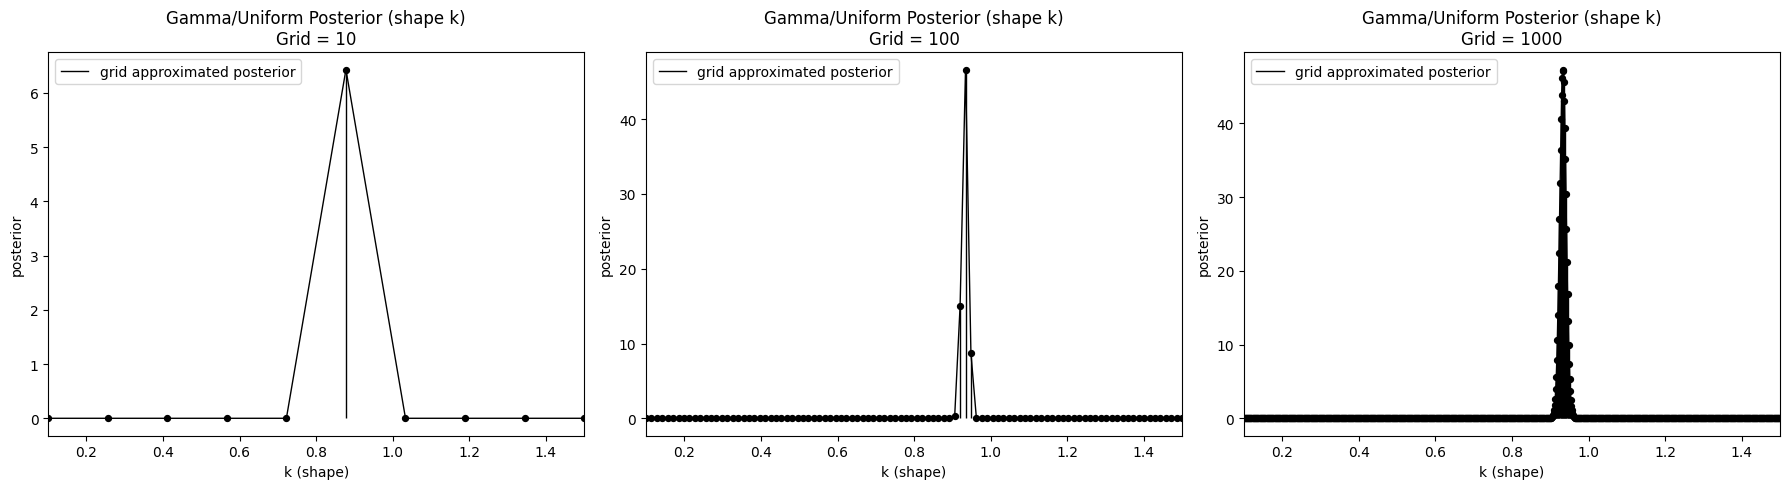

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaln

# ------------------------------------
# Load data
# ------------------------------------
df = pd.read_csv("datast.csv")
eto = df['et0_fao_evapotranspiration (mm)'].dropna().values

# Remove zeros (Gamma likelihood can't take x=0 when shape<1)
eto = eto[eto > 0]
n = len(eto)

theta = eto.mean()

# ------------------------------------
# Prior on k (Uniform)
# ------------------------------------
k_min, k_max = 0.1, 1.5

def log_posterior_k(k):
    # log likelihood under Gamma(k, theta)
    # log f(x|k,theta) = (k-1)*log(x) - x/theta - k*log(theta) - gammaln(k)
    return np.sum((k-1)*np.log(eto) - eto/theta - k*np.log(theta) - gammaln(k))

# ------------------------------------
# TRUE posterior curve (dense)
# ------------------------------------
k_dense = np.linspace(k_min, k_max, 2000)
log_post_dense = np.array([log_posterior_k(k) for k in k_dense])
log_post_dense -= np.max(log_post_dense)           # avoid overflow
post_dense = np.exp(log_post_dense)
post_dense /= np.trapz(post_dense, k_dense)        # normalize

# ------------------------------------
# GRID APPROXIMATIONS
# ------------------------------------
grid_sizes = [10, 100, 1000]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, G in zip(axes, grid_sizes):

    k_grid = np.linspace(k_min, k_max, G)

    # Compute log posterior on grid
    log_post_grid = np.array([log_posterior_k(k) for k in k_grid])
    log_post_grid -= np.max(log_post_grid)
    post_grid = np.exp(log_post_grid)
    post_grid /= np.trapz(post_grid, k_grid)   # normalize

    # ---- Grid STEM plot (vertical lines + points) ----
    ax.vlines(k_grid, ymin=0, ymax=post_grid, color='black', linewidth=1)
    ax.scatter(k_grid, post_grid, color='black', s=18)

    # ---- NEW: connect the grid points with a line ----
    ax.plot(k_grid, post_grid, color='black', linewidth=1, label= "grid approximated posterior")

    ax.set_title(f"Gamma/Uniform Posterior (shape k)\nGrid = {G}")
    ax.set_xlabel("k (shape)")
    ax.set_ylabel("posterior")
    ax.set_xlim(k_min, k_max)
    ax.legend()

plt.tight_layout()
plt.show()


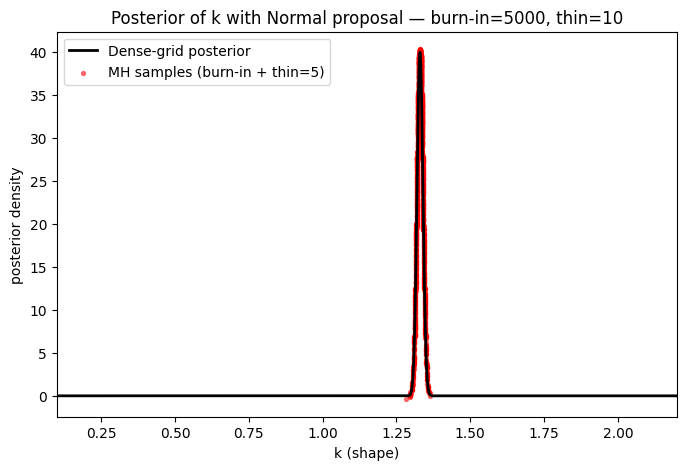

n data = 9144
theta (fixed) = 15.4766
MH iterations = 25000
Burn-in = 5000, thin = 10
Proposal sd = 0.12
Acceptance rate = 0.106
Posterior mean (after thinning) = 1.3296
Posterior sd (after thinning) = 0.0105


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaln
import seaborn as sns

# -------------------------
# Metropolis-Hastings with Normal proposal on k (additive)
# -------------------------

# Load data
df = pd.read_csv("datast.csv")
wind = df['wind_speed_100m (km/h)'].dropna().values
wind = wind[wind > 0]
n = len(wind)

theta = wind.mean()    # fixed scale parameter

# log posterior (unnormalized)
k_min, k_max = 0.1, 2.2
def log_post_k(k):
    if (k <= k_min) or (k >= k_max):
        return -np.inf
    return np.sum((k-1)*np.log(wind) - wind/theta - k*np.log(theta) - gammaln(k))

# dense-grid reference posterior
k_dense = np.linspace(k_min, k_max, 4000)
logpd = np.array([log_post_k(k) for k in k_dense])
logpd -= np.max(logpd)
post_dense = np.exp(logpd)
post_dense /= np.trapz(post_dense, k_dense)

# MH parameters
n_iter = 25000
burn_in = 5000
thin = 10
proposal_sd = 0.12

# initialize
mean_w = wind.mean(); sd_w = wind.std(ddof=1)
k_init = max(0.5, (mean_w/sd_w)**2)
k_current = k_init
logpost_current = log_post_k(k_current)

ks = np.empty(n_iter)
ks[0] = k_current
accept_count = 0

# MH sampling loop
for i in range(1, n_iter):
    k_prop = k_current + np.random.normal(scale=proposal_sd)

    # reflect boundaries
    if k_prop <= k_min:
        k_prop = k_min + (k_min - k_prop)
    if k_prop >= k_max:
        k_prop = k_max - (k_prop - k_max)

    logpost_prop = log_post_k(k_prop)
    log_alpha = logpost_prop - logpost_current

    if np.log(np.random.rand()) < log_alpha:
        k_current = k_prop
        logpost_current = logpost_prop
        accept_count += 1

    ks[i] = k_current

accept_rate = accept_count / (n_iter - 1)

# -------------------------
# APPLY BURN-IN AND THIN
# -------------------------
samples = ks[burn_in::thin]   # <<--- thinning applied here

# compute density for scatter plot
sample_densities = np.interp(samples, k_dense, post_dense)
y_jitter = (np.random.rand(len(samples)) - 0.5) * post_dense.max() * 0.02

# -------------------------
# POSTERIOR PLOT: scatter of thinned samples
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(k_dense, post_dense, color='black', lw=2, label="Dense-grid posterior")

plt.scatter(samples, sample_densities + y_jitter,
            s=8, alpha=0.5, color='red', label="MH samples (burn-in + thin=5)")

plt.xlabel("k (shape)")
plt.ylabel("posterior density")
plt.title(f"Posterior of k with Normal proposal — burn-in={burn_in}, thin={thin}")
plt.xlim(k_min, k_max)
plt.legend()
plt.show()

# summary
print(f"n data = {n}")
print(f"theta (fixed) = {theta:.4f}")
print(f"MH iterations = {n_iter}")
print(f"Burn-in = {burn_in}, thin = {thin}")
print(f"Proposal sd = {proposal_sd}")
print(f"Acceptance rate = {accept_rate:.3f}")
print(f"Posterior mean (after thinning) = {np.mean(samples):.4f}")
print(f"Posterior sd (after thinning) = {np.std(samples):.4f}")



Posterior summary (Daytime Only Model):

Intercept         : mean=33.1528, sd=0.1709
Humidity          : mean=-0.1148, sd=0.0021
ShortwaveRadiation: mean=0.0037, sd=0.0002

Posterior mean sigma² = 6.0574



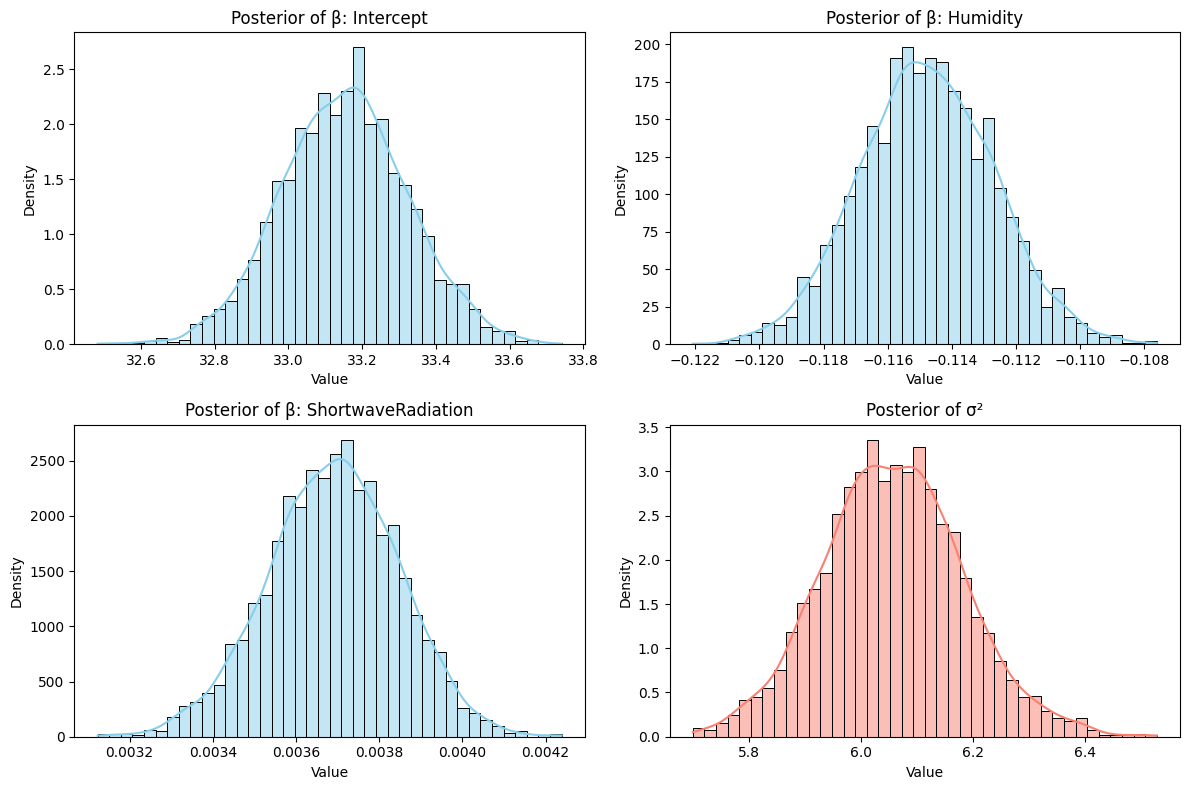

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gammaln

# -------------------------
# LOAD & FILTER DATA (DAYTIME ONLY)
# -------------------------
df = pd.read_csv("datast.csv")

df = df[df['is_day ()'] == 1]   # keep only daytime rows

Y = df['temperature_2m (°C)'].values

X = df[[
    'relative_humidity_2m (%)',
    'shortwave_radiation (W/m²)'
]].values

# Remove missing rows
mask = ~np.isnan(Y) & ~np.isnan(X).any(axis=1)
Y = Y[mask]
X = X[mask]

n, p = X.shape

# Add intercept
X = np.column_stack((np.ones(n), X))
p = p + 1

# -------------------------
# PRIOR PARAMETERS (weak priors)
# -------------------------
Lambda0 = 0.01 * np.eye(p)   # weak Gaussian prior
a0 = 1.0                     # IG shape
b0 = 1.0                     # IG scale

# -------------------------
# GIBBS SETTINGS
# -------------------------
n_iter = 20000
burn = 5000
thin = 5

beta_samples = np.zeros((n_iter, p))
sigma2_samples = np.zeros(n_iter)

# Initial values
beta = np.zeros(p)
sigma2 = 1.0
XT = X.T

# -------------------------
# GIBBS SAMPLER
# -------------------------
for t in range(n_iter):

    # ---- SAMPLE β | σ², y ----
    V_beta_inv = Lambda0 + XT @ X
    V_beta = np.linalg.inv(V_beta_inv)
    mu_beta = V_beta @ (XT @ Y)

    beta = np.random.multivariate_normal(mu_beta, sigma2 * V_beta)

    # ---- SAMPLE σ² | β, y ----
    resid = Y - X @ beta
    a_post = a0 + n/2
    b_post = b0 + 0.5 * np.dot(resid, resid)

    sigma2 = 1 / np.random.gamma(a_post, 1/b_post)

    # Store
    beta_samples[t] = beta
    sigma2_samples[t] = sigma2


# -------------------------
# BURN-IN + THINNING
# -------------------------
beta_post = beta_samples[burn::thin]
sigma2_post = sigma2_samples[burn::thin]

coef_names = [
    "Intercept",
    "Humidity",
    "ShortwaveRadiation"
]

# -------------------------
# POSTERIOR SUMMARY
# -------------------------
print("\nPosterior summary (Daytime Only Model):\n")
for i, name in enumerate(coef_names):
    print(f"{name:18s}: mean={beta_post[:,i].mean():.4f}, sd={beta_post[:,i].std():.4f}")

print(f"\nPosterior mean sigma² = {sigma2_post.mean():.4f}\n")


# =======================================================
# 1) HISTOGRAM + KDE FOR EACH COEFFICIENT
# =======================================================
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for i, name in enumerate(coef_names):
    sns.histplot(beta_post[:, i], bins=40, kde=True, stat="density",
                 ax=axes[i], color="skyblue")
    axes[i].set_title(f"Posterior of β: {name}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

# Sigma² panel
sns.histplot(sigma2_post, bins=40, kde=True, stat="density",
             ax=axes[-1], color="salmon")
axes[-1].set_title("Posterior of σ²")
axes[-1].set_xlabel("Value")

plt.tight_layout()
plt.show()


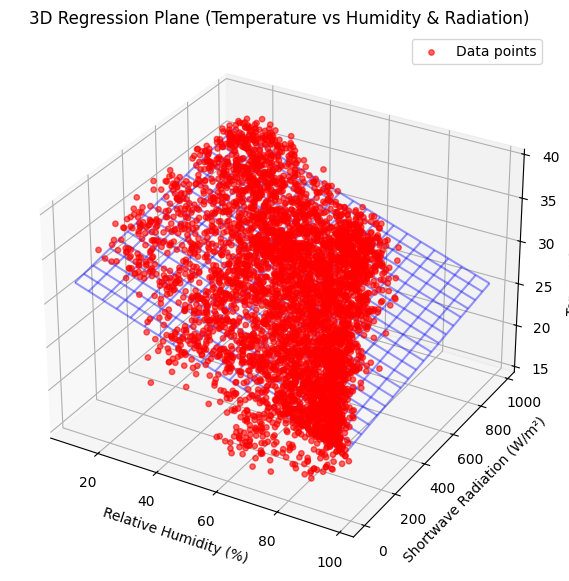

[ 3.31534067e+01 -1.14790415e-01  3.68963050e-03]


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Filter daytime only
df = df[df['is_day ()'] == 1]

# Extract variables
humidity = df['relative_humidity_2m (%)'].values
radiation = df['shortwave_radiation (W/m²)'].values
temperature = df['temperature_2m (°C)'].values

# Remove NaNs
mask = ~np.isnan(humidity) & ~np.isnan(radiation) & ~np.isnan(temperature)
humidity = humidity[mask]
radiation = radiation[mask]
temperature = temperature[mask]

# Fit a plane: temp = b0 + b1*humidity + b2*radiation
X = np.column_stack((np.ones(len(humidity)), humidity, radiation))
beta, _, _, _ = np.linalg.lstsq(X, temperature, rcond=None)
b0, b1, b2 = beta

# Create meshgrid (lower resolution to avoid overload)
h_grid = np.linspace(min(humidity), max(humidity), 20)
r_grid = np.linspace(min(radiation), max(radiation), 20)
H, R = np.meshgrid(h_grid, r_grid)
T_plane = b0 + b1 * H + b2 * R

# Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter original data points
ax.scatter(humidity, radiation, temperature,
           color='red', s=15, alpha=0.6, label='Data points')

# Wireframe plane
ax.plot_wireframe(H, R, T_plane, color='blue', alpha=0.4)

# Labels
ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("Shortwave Radiation (W/m²)")
ax.set_zlabel("Temperature (°C)")
ax.set_title("3D Regression Plane (Temperature vs Humidity & Radiation)")
ax.legend()

plt.show()
print(beta)
